Name: Lama Alfreah.

# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [1]:
import pandas as pd
import sklearn
from sklearn.datasets import fetch_openml

### Step 1. Load the data

In [2]:
df= pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv")
df.head()

,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
data = df['Hours_Studied']   # feature
target = df['Marks']             # target

### Step 2.b print the type of each

In [4]:
display(df['Hours_Studied'] .dtype)
display(df['Marks'] .dtype)

dtype('float64')

dtype('float64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

Target is numerical value and task is regression 

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Hours_Studied  100 non-null    float64
 1   Marks          100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [6]:
df.describe()

,Hours_Studied,Marks
count,100.000000,100.000000
mean,5.376300,46.360200
std,2.593013,14.284805
min,1.050000,20.190000
25%,3.175000,33.675000
50%,5.565000,47.485000
75%,7.255000,57.377500
max,9.870000,73.260000


### Step 5. Plot the feature vs the target

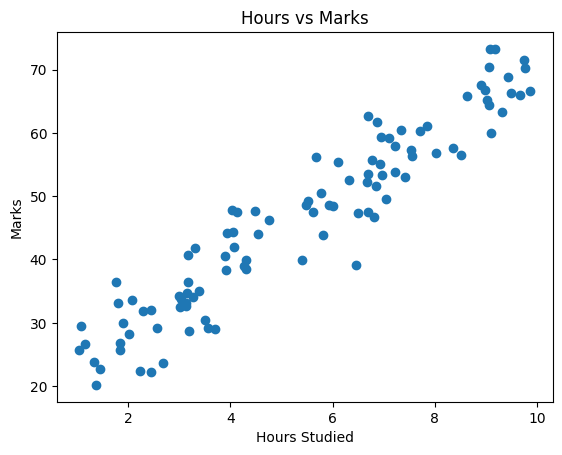

In [7]:
import matplotlib.pyplot as plt

plt.scatter(data, target)
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Hours vs Marks")
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

The relationship between the feature and the target is increasing.

### Step 7. Initialize a `LinearRegression` model

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, target,
    test_size=0.20,
    random_state=42,
)

### Step 9.a Train the model on the training set

In [12]:
model.fit(df, target)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the model

In [13]:
slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)

Slope: 3.4241871678515524e-16
Intercept: 7.105427357601002e-15


### Step 9.c how much marks do we get per 1 hour of study?

In [15]:
1*slope

np.float64(3.4241871678515524e-16)

### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [16]:
increase = slope * (1/6)
print(increase)

5.70697861308592e-17


### Step 9.e if one doesn't study at all, how much marks do they get?

In [17]:
print(intercept)

7.105427357601002e-15


### Step 10. Evaluate the model on the test set

### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

### Step 12. Plot the data and the regression line